# SYN Flood Detection using Decision Tree Classifier
## IoT Network Traffic Analysis

This notebook performs:
1. **Data Preprocessing** - Cleaning raw packet capture data
2. **Feature Engineering** - Extracting network traffic features from packet metadata
3. **Exploratory Data Analysis (EDA)** - Understanding traffic patterns
4. **Decision Tree Classification** - Predicting normal vs attack traffic

In [13]:
# Section 1: Import Libraries and Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('syn_flood.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (7067, 8)

Column Types:
No.              int64
Time           float64
Source             str
Destination        str
Protocol           str
Length           int64
Info               str
attack           int64
dtype: object

First 5 rows:


,No.,Time,Source,Destination,Protocol,Length,Info,attack
0,1,0.000000,192.168.56.113,192.168.56.112,TCP,74,40612 > 502 [SYN] Seq=0 Win=64240 Len=0 MSS=...,0
1,2,0.000049,192.168.56.112,192.168.56.113,TCP,74,"502 > 40612 [SYN, ACK] Seq=0 Ack=1 Win=65160...",0
2,3,0.000583,192.168.56.113,192.168.56.112,TCP,66,40612 > 502 [ACK] Seq=1 Ack=1 Win=64256 Len=...,0
3,4,0.001035,192.168.56.113,192.168.56.112,Modbus/TCP,78,"Query: Trans: 52673; Unit: 1, Func: 3: ...",0
4,5,0.001046,192.168.56.112,192.168.56.113,TCP,66,502 > 40612 [ACK] Seq=1 Ack=13 Win=65152 Len...,0


In [14]:
# Check for missing values and basic stats
print("Missing Values:")
print(df.isnull().sum())
print(f"\nBasic Statistics:")
df.describe()

Missing Values:
No.            0
Time           0
Source         0
Destination    0
Protocol       0
Length         0
Info           0
attack         0
dtype: int64

Basic Statistics:


,No.,Time,Length,attack
count,7067.000000,7067.000000,7067.000000,7067.000000
mean,3534.000000,87.532620,75.991793,0.009056
std,2040.211509,50.750701,9.082753,0.094739
min,1.000000,0.000000,42.000000,0.000000
25%,1767.500000,42.676183,78.000000,0.000000
50%,3534.000000,88.054956,78.000000,0.000000
75%,5300.500000,131.857082,78.000000,0.000000
max,7067.000000,179.125657,285.000000,1.000000


## Section 2: Initial Data Exploration and Cleaning

In [15]:
# Explore unique values in key columns
print("Unique Protocols:", df['Protocol'].unique())
print(f"\nProtocol Value Counts:\n{df['Protocol'].value_counts()}")
print(f"\nUnique Sources: {df['Source'].nunique()} IPs")
print(f"Unique Destinations: {df['Destination'].nunique()} IPs")
print(f"\nAttack Label Distribution:\n{df['attack'].value_counts()}")
print(f"\nAttack ratio: {df['attack'].mean()*100:.2f}%")

Unique Protocols: <ArrowStringArray>
['TCP', 'Modbus/TCP', 'ARP', 'BROWSER', 'NBNS', 'SSDP', 'ICMPv6', 'MDNS']
Length: 8, dtype: str

Protocol Value Counts:
Protocol
Modbus/TCP    5604
TCP           1195
ARP            238
NBNS            20
SSDP             4
BROWSER          3
MDNS             2
ICMPv6           1
Name: count, dtype: int64

Unique Sources: 32 IPs
Unique Destinations: 59 IPs

Attack Label Distribution:
attack
0    7003
1      64
Name: count, dtype: int64

Attack ratio: 0.91%


In [16]:
# Parse TCP flags from the Info column
df['syn_flag'] = df['Info'].str.contains(r'\[SYN\]', regex=True, na=False).astype(int)
df['ack_flag'] = df['Info'].str.contains(r'\[ACK\]', regex=True, na=False).astype(int)
df['syn_ack_flag'] = df['Info'].str.contains(r'\[SYN, ACK\]', regex=True, na=False).astype(int)
df['fin_flag'] = df['Info'].str.contains(r'\[FIN', regex=True, na=False).astype(int)
df['rst_flag'] = df['Info'].str.contains(r'\[RST', regex=True, na=False).astype(int)
df['is_retransmission'] = df['Info'].str.contains('Retransmission', na=False).astype(int)

# Ensure Time is float
df['Time'] = df['Time'].astype(float)

# Check for any malformed rows
print("Rows with null Info:", df['Info'].isnull().sum())
print("\nFlag distributions:")
for flag in ['syn_flag', 'ack_flag', 'syn_ack_flag', 'fin_flag', 'rst_flag', 'is_retransmission']:
    print(f"  {flag}: {df[flag].sum()}")

# Check attack samples' flags
print("\n--- Attack samples flag profile ---")
print(df[df['attack']==1][['syn_flag','ack_flag','syn_ack_flag','is_retransmission']].sum())

Rows with null Info: 0

Flag distributions:
  syn_flag: 66
  ack_flag: 939
  syn_ack_flag: 186
  fin_flag: 4
  rst_flag: 0
  is_retransmission: 200

--- Attack samples flag profile ---
syn_flag             64
ack_flag              0
syn_ack_flag          0
is_retransmission    40
dtype: int64


## Section 3: Feature Engineering from Raw Packet Data

We engineer network-level features from the raw packet capture data using rolling time windows and per-source-IP aggregations. These features capture the behavioral patterns that distinguish SYN flood attacks from normal Modbus/TCP IoT traffic.

In [17]:
# Feature Engineering

# 1. Protocol binary features
df['is_modbus'] = (df['Protocol'] == 'Modbus/TCP').astype(int)
df['is_tcp'] = (df['Protocol'] == 'TCP').astype(int)
df['is_arp'] = (df['Protocol'] == 'ARP').astype(int)

# 2. Packet length (already numeric)
df['packet_length'] = df['Length'].astype(int)

# 3. Parse source and destination ports from Info
def extract_ports(info):
    """Extract src_port > dst_port from Info field like '40612  >  502 [SYN]...'"""
    import re
    match = re.search(r'(\d+)\s+>\s+(\d+)', str(info))
    if match:
        return int(match.group(1)), int(match.group(2))
    return np.nan, np.nan

ports = df['Info'].apply(extract_ports)
df['src_port'] = ports.apply(lambda x: x[0])
df['dst_port'] = ports.apply(lambda x: x[1])

# 4. Time delta between consecutive packets
df = df.sort_values('Time').reset_index(drop=True)
df['time_delta'] = df['Time'].diff().fillna(0)

# 5. Rolling window features (window of 50 packets ~ approximation of time window)
WINDOW = 50

# Packets per second in sliding window
df['window_time_span'] = df['Time'].rolling(window=WINDOW, min_periods=1).apply(lambda x: x.iloc[-1] - x.iloc[0], raw=False)
df['packets_per_second'] = WINDOW / df['window_time_span'].replace(0, np.nan)
df['packets_per_second'] = df['packets_per_second'].fillna(0).clip(upper=10000)

# 6. SYN count in rolling window
df['syn_count_window'] = df['syn_flag'].rolling(window=WINDOW, min_periods=1).sum()

# 7. SYN-ACK count in rolling window
df['syn_ack_count_window'] = df['syn_ack_flag'].rolling(window=WINDOW, min_periods=1).sum()

# 8. SYN to ACK ratio in window
df['syn_to_ack_ratio'] = df['syn_count_window'] / (df['syn_ack_count_window'] + 1)

# 9. Retransmission count in window
df['retransmission_count_window'] = df['is_retransmission'].rolling(window=WINDOW, min_periods=1).sum()

# 10. Unique source IPs in rolling window (using a custom approach)
def rolling_unique_count(series, window):
    """Count unique values in rolling window"""
    result = []
    for i in range(len(series)):
        start = max(0, i - window + 1)
        result.append(series.iloc[start:i+1].nunique())
    return result

df['unique_src_ips_window'] = rolling_unique_count(df['Source'], WINDOW)

# 11. Same source IP frequency in window
src_counts = df.groupby('Source').cumcount() + 1
df['src_ip_cumulative_freq'] = src_counts

# 12. Half-open connection detection (SYN without completing handshake)
# Track: SYN sent from source but no corresponding SYN-ACK followed by ACK
df['is_syn_only'] = ((df['syn_flag'] == 1) & (df['syn_ack_flag'] == 0)).astype(int)
df['half_open_window'] = df['is_syn_only'].rolling(window=WINDOW, min_periods=1).sum()

print(f"Feature engineering complete. New shape: {df.shape}")
print(f"\nEngineered features:")
new_cols = ['syn_flag', 'ack_flag', 'syn_ack_flag', 'fin_flag', 'rst_flag', 
            'is_retransmission', 'is_modbus', 'is_tcp', 'is_arp', 'packet_length',
            'src_port', 'dst_port', 'time_delta', 'packets_per_second',
            'syn_count_window', 'syn_ack_count_window', 'syn_to_ack_ratio',
            'retransmission_count_window', 'unique_src_ips_window', 
            'src_ip_cumulative_freq', 'is_syn_only', 'half_open_window']
for c in new_cols:
    print(f"  {c}: min={df[c].min():.2f}, max={df[c].max():.2f}, mean={df[c].mean():.2f}")

Feature engineering complete. New shape: (7067, 31)

Engineered features:
  syn_flag: min=0.00, max=1.00, mean=0.01
  ack_flag: min=0.00, max=1.00, mean=0.13
  syn_ack_flag: min=0.00, max=1.00, mean=0.03
  fin_flag: min=0.00, max=1.00, mean=0.00
  rst_flag: min=0.00, max=0.00, mean=0.00
  is_retransmission: min=0.00, max=1.00, mean=0.03
  is_modbus: min=0.00, max=1.00, mean=0.79
  is_tcp: min=0.00, max=1.00, mean=0.17
  is_arp: min=0.00, max=1.00, mean=0.03
  packet_length: min=42.00, max=285.00, mean=75.99
  src_port: min=502.00, max=64871.00, mean=33817.66
  dst_port: min=502.00, max=64871.00, mean=5484.71
  time_delta: min=0.00, max=1.02, mean=0.03
  packets_per_second: min=0.00, max=10000.00, mean=63.72
  syn_count_window: min=0.00, max=2.00, mean=0.47
  syn_ack_count_window: min=0.00, max=7.00, mean=1.32
  syn_to_ack_ratio: min=0.00, max=1.00, mean=0.16
  retransmission_count_window: min=0.00, max=7.00, mean=1.42
  unique_src_ips_window: min=1.00, max=7.00, mean=3.55
  src_ip_cumu

## Section 4: Exploratory Data Analysis - Protocol and Attack Distribution

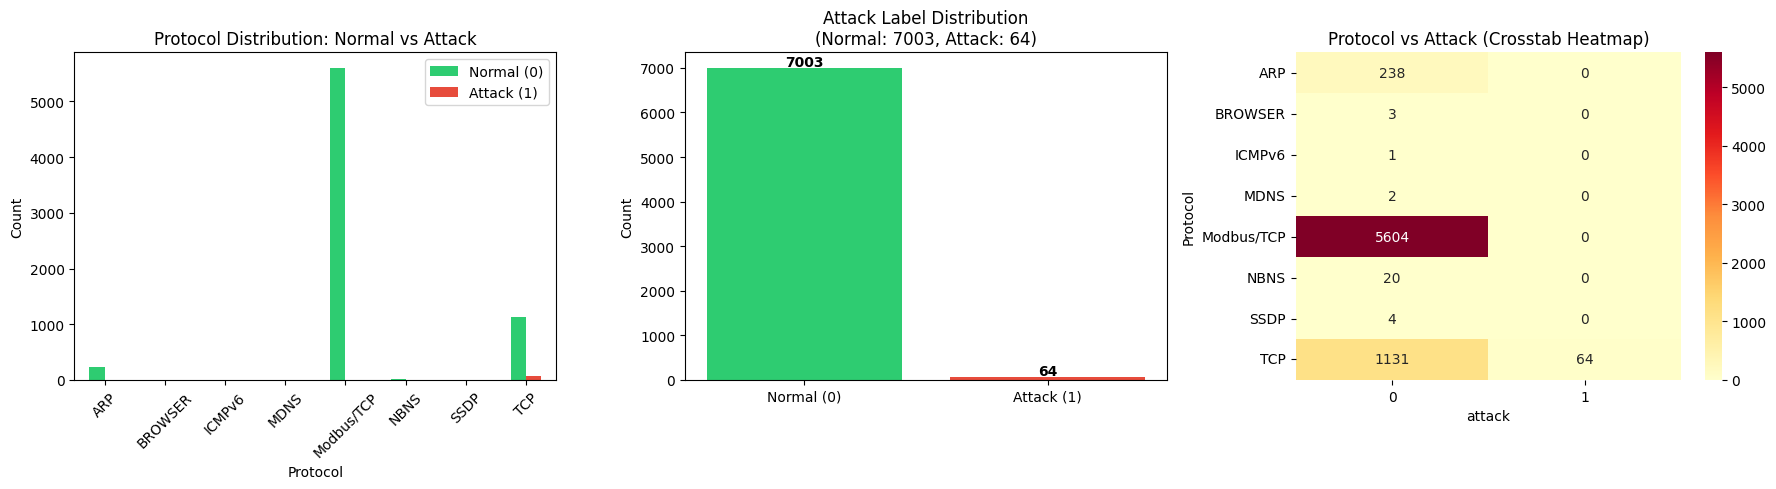


Key Observations:
- Attack traffic is exclusively TCP (SYN packets)
- Dataset is highly imbalanced: 7003 normal vs 64 attack (0.9%)
- Normal traffic includes Modbus/TCP (IoT protocol), TCP, and ARP


In [18]:
# EDA: Protocol and Attack Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Protocol distribution by class
ct = pd.crosstab(df['Protocol'], df['attack'])
ct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Protocol Distribution: Normal vs Attack')
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Count')
axes[0].legend(['Normal (0)', 'Attack (1)'])
axes[0].tick_params(axis='x', rotation=45)

# 2. Class distribution
attack_counts = df['attack'].value_counts()
axes[1].bar(['Normal (0)', 'Attack (1)'], attack_counts.values, 
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'Attack Label Distribution\n(Normal: {attack_counts[0]}, Attack: {attack_counts[1]})')
axes[1].set_ylabel('Count')
for i, v in enumerate(attack_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 3. Crosstab heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Protocol vs Attack (Crosstab Heatmap)')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Attack traffic is exclusively TCP (SYN packets)")
print(f"- Dataset is highly imbalanced: {attack_counts[0]} normal vs {attack_counts[1]} attack ({attack_counts[1]/len(df)*100:.1f}%)")
print("- Normal traffic includes Modbus/TCP (IoT protocol), TCP, and ARP")

## Section 5: EDA - Temporal Traffic Patterns

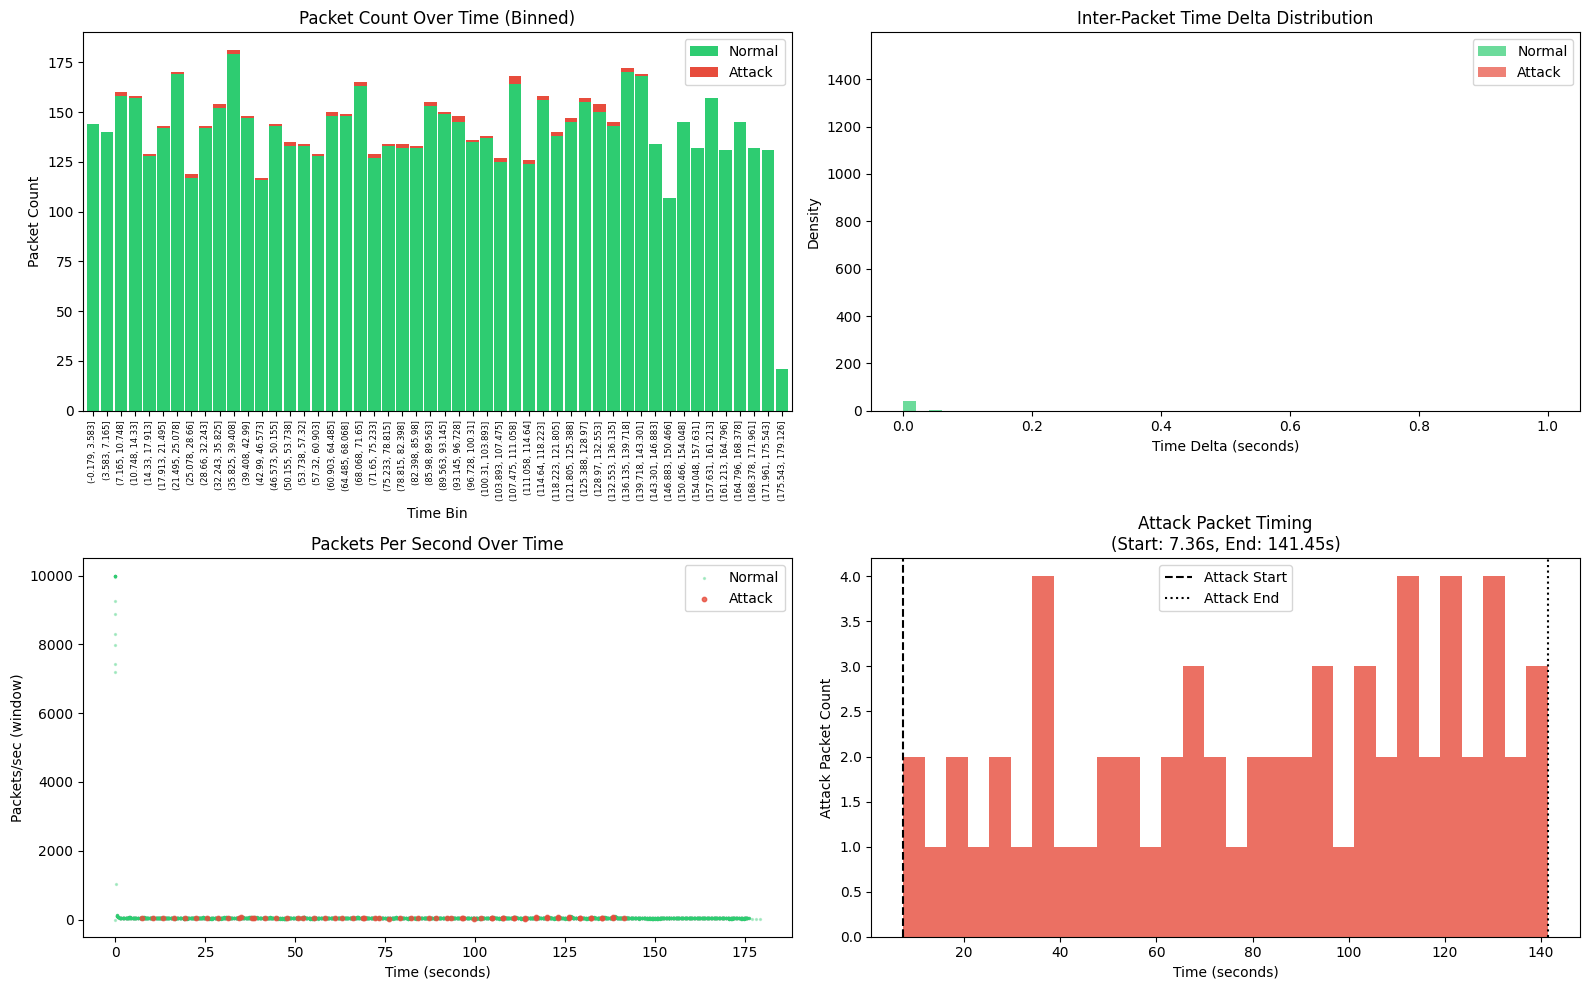


Attack window: 7.36s to 141.45s
Attack duration: 134.10s


In [19]:
# EDA: Temporal Traffic Patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Packet count over time bins (colored by attack)
df['time_bin'] = pd.cut(df['Time'], bins=50)
time_attack = df.groupby(['time_bin', 'attack']).size().unstack(fill_value=0)
time_attack.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], width=0.9)
axes[0, 0].set_title('Packet Count Over Time (Binned)')
axes[0, 0].set_xlabel('Time Bin')
axes[0, 0].set_ylabel('Packet Count')
axes[0, 0].legend(['Normal', 'Attack'])
axes[0, 0].tick_params(axis='x', rotation=90, labelsize=6)

# 2. Time delta distribution: Normal vs Attack
normal_td = df[df['attack']==0]['time_delta'].clip(upper=1)
attack_td = df[df['attack']==1]['time_delta'].clip(upper=1)
axes[0, 1].hist(normal_td, bins=50, alpha=0.7, label='Normal', color='#2ecc71', density=True)
axes[0, 1].hist(attack_td, bins=50, alpha=0.7, label='Attack', color='#e74c3c', density=True)
axes[0, 1].set_title('Inter-Packet Time Delta Distribution')
axes[0, 1].set_xlabel('Time Delta (seconds)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# 3. Packets per second over time
axes[1, 0].scatter(df[df['attack']==0]['Time'], df[df['attack']==0]['packets_per_second'], 
                   alpha=0.3, s=2, c='#2ecc71', label='Normal')
axes[1, 0].scatter(df[df['attack']==1]['Time'], df[df['attack']==1]['packets_per_second'], 
                   alpha=0.8, s=10, c='#e74c3c', label='Attack')
axes[1, 0].set_title('Packets Per Second Over Time')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Packets/sec (window)')
axes[1, 0].legend()

# 4. Identify attack time region
attack_times = df[df['attack']==1]['Time']
axes[1, 1].hist(attack_times, bins=30, color='#e74c3c', alpha=0.8)
axes[1, 1].set_title(f'Attack Packet Timing\n(Start: {attack_times.min():.2f}s, End: {attack_times.max():.2f}s)')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Attack Packet Count')
axes[1, 1].axvline(x=attack_times.min(), color='black', linestyle='--', label='Attack Start')
axes[1, 1].axvline(x=attack_times.max(), color='black', linestyle=':', label='Attack End')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Clean up temp column
df.drop('time_bin', axis=1, inplace=True)

print(f"\nAttack window: {attack_times.min():.2f}s to {attack_times.max():.2f}s")
print(f"Attack duration: {attack_times.max() - attack_times.min():.2f}s")

## Section 6: EDA - Connection-Level Statistics

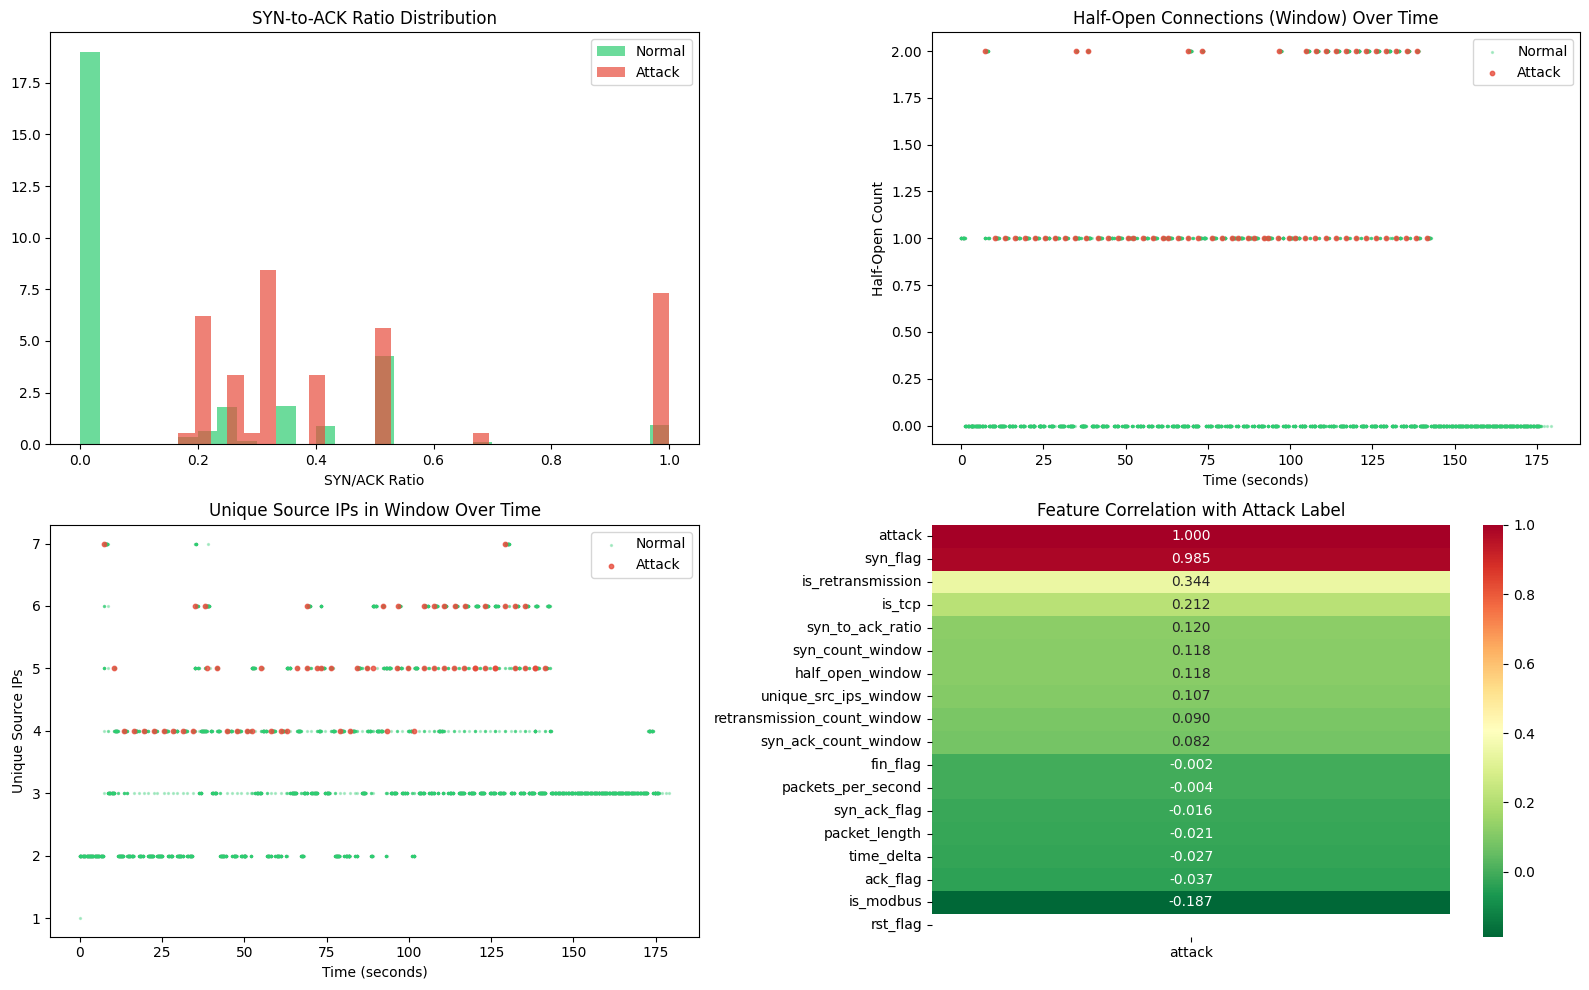


Key distinguishing features (by correlation with attack):
  syn_flag: 0.9846
  is_retransmission: 0.3440
  is_tcp: 0.2119
  is_modbus: 0.1871
  syn_to_ack_ratio: 0.1202
  syn_count_window: 0.1177
  half_open_window: 0.1177
  unique_src_ips_window: 0.1072


In [20]:
# EDA: Connection-Level Statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. SYN-to-ACK ratio distribution
normal_ratio = df[df['attack']==0]['syn_to_ack_ratio']
attack_ratio = df[df['attack']==1]['syn_to_ack_ratio']
axes[0, 0].hist(normal_ratio, bins=30, alpha=0.7, label='Normal', color='#2ecc71', density=True)
axes[0, 0].hist(attack_ratio, bins=30, alpha=0.7, label='Attack', color='#e74c3c', density=True)
axes[0, 0].set_title('SYN-to-ACK Ratio Distribution')
axes[0, 0].set_xlabel('SYN/ACK Ratio')
axes[0, 0].legend()

# 2. Half-open connections over time
axes[0, 1].scatter(df[df['attack']==0]['Time'], df[df['attack']==0]['half_open_window'], 
                   alpha=0.3, s=2, c='#2ecc71', label='Normal')
axes[0, 1].scatter(df[df['attack']==1]['Time'], df[df['attack']==1]['half_open_window'], 
                   alpha=0.8, s=10, c='#e74c3c', label='Attack')
axes[0, 1].set_title('Half-Open Connections (Window) Over Time')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Half-Open Count')
axes[0, 1].legend()

# 3. Unique source IPs in window
axes[1, 0].scatter(df[df['attack']==0]['Time'], df[df['attack']==0]['unique_src_ips_window'], 
                   alpha=0.3, s=2, c='#2ecc71', label='Normal')
axes[1, 0].scatter(df[df['attack']==1]['Time'], df[df['attack']==1]['unique_src_ips_window'], 
                   alpha=0.8, s=10, c='#e74c3c', label='Attack')
axes[1, 0].set_title('Unique Source IPs in Window Over Time')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Unique Source IPs')
axes[1, 0].legend()

# 4. Correlation heatmap of engineered features with attack label
feature_cols = ['syn_flag', 'ack_flag', 'syn_ack_flag', 'fin_flag', 'rst_flag',
                'is_retransmission', 'is_modbus', 'is_tcp', 'packet_length',
                'time_delta', 'packets_per_second', 'syn_count_window',
                'syn_ack_count_window', 'syn_to_ack_ratio', 
                'retransmission_count_window', 'unique_src_ips_window',
                'half_open_window', 'attack']
corr = df[feature_cols].corr()
sns.heatmap(corr[['attack']].sort_values(by='attack', ascending=False), 
            annot=True, cmap='RdYlGn_r', ax=axes[1, 1], fmt='.3f')
axes[1, 1].set_title('Feature Correlation with Attack Label')

plt.tight_layout()
plt.show()

print("\nKey distinguishing features (by correlation with attack):")
corr_attack = corr['attack'].drop('attack').abs().sort_values(ascending=False)
for feat, val in corr_attack.head(8).items():
    print(f"  {feat}: {val:.4f}")

## Section 7: Data Preparation for Modeling (Leakage-Aware)

In [21]:
# Data Preparation for Modeling (Leakage-Aware)
FEATURE_COLS = [
    'packet_length',
    'time_delta',
    'packets_per_second',
    'syn_count_window',
    'syn_ack_count_window',
    'syn_to_ack_ratio',
    'retransmission_count_window',
    'unique_src_ips_window',
    'half_open_window'
 ]

X = df[FEATURE_COLS].copy()
y = df['attack'].copy()

# Handle NaN values from feature engineering
print("NaN counts before handling:")
nan_counts = X.isnull().sum()
print(nan_counts[nan_counts > 0])
X = X.fillna(0)

# Chronological split with class-balance safety check
def find_valid_time_split(labels, low=0.60, high=0.90, steps=31):
    n = len(labels)
    for frac in np.linspace(low, high, steps):
        idx = int(n * frac)
        y_left = labels.iloc[:idx]
        y_right = labels.iloc[idx:]
        if y_left.nunique() == 2 and y_right.nunique() == 2:
            return idx
    return int(n * 0.8)

split_idx = find_valid_time_split(y)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
train_idx, test_idx = X_train.index, X_test.index

print(f"\nChronological split index: {split_idx} / {len(df)}")
print(f"Training set: {X_train.shape[0]} samples ({y_train.sum()} attacks)")
print(f"Test set: {X_test.shape[0]} samples ({y_test.sum()} attacks)")
print(f"Attack ratio - Train: {y_train.mean()*100:.2f}%, Test: {y_test.mean()*100:.2f}%")
print(f"Feature count after bloat removal: {len(FEATURE_COLS)}")

NaN counts before handling:
Series([], dtype: int64)

Chronological split index: 4240 / 7067
Training set: 4240 samples (41 attacks)
Test set: 2827 samples (23 attacks)
Attack ratio - Train: 0.97%, Test: 0.81%
Feature count after bloat removal: 9


## Section 8: Train Decision Tree Classifier (Chronological Split)

Cross-Validation F1 Scores (training only, 5-fold):
  max_depth=3: F1=0.7170
  max_depth=5: F1=0.9632 <-- best
  max_depth=7: F1=0.9632
  max_depth=10: F1=0.9632
  max_depth=None: F1=0.9632

Best max_depth: 5
Best CV F1 Score: 0.9632


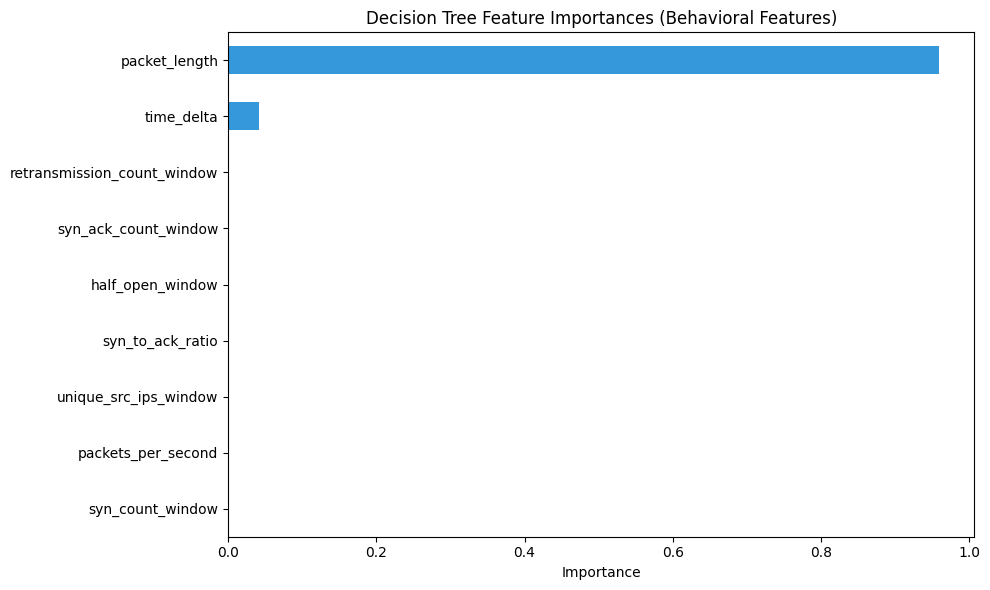

In [22]:
# Train Decision Tree with hyperparameter tuning via cross-validation on training set only
cv_splits = min(5, max(2, int(y_train.value_counts().min())))
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

best_depth = None
best_score = -1
results = {}

for depth in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    mean_score = scores.mean()
    results[str(depth)] = mean_score
    if mean_score > best_score:
        best_score = mean_score
        best_depth = depth

print(f"Cross-Validation F1 Scores (training only, {cv_splits}-fold):")
for depth, score in results.items():
    marker = " <-- best" if depth == str(best_depth) else ""
    print(f"  max_depth={depth}: F1={score:.4f}{marker}")

# Train final model with best depth
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

print(f"\nBest max_depth: {best_depth}")
print(f"Best CV F1 Score: {best_score:.4f}")

# Feature importances
importances = pd.Series(dt_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Decision Tree Feature Importances (Behavioral Features)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Section 9: Evaluate Decision Tree Model (Generalization + Overfitting Checks)

DECISION TREE - GENERALIZATION REPORT
Train Accuracy: 0.9998 | Test Accuracy: 0.9989
Train F1: 0.9880 | Test F1: 0.9388 | F1 Gap: 0.0492
Dummy Baseline Test Accuracy: 0.9919
Dummy Baseline Test F1: 0.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2804
      Attack       0.88      1.00      0.94        23

    accuracy                           1.00      2827
   macro avg       0.94      1.00      0.97      2827
weighted avg       1.00      1.00      1.00      2827



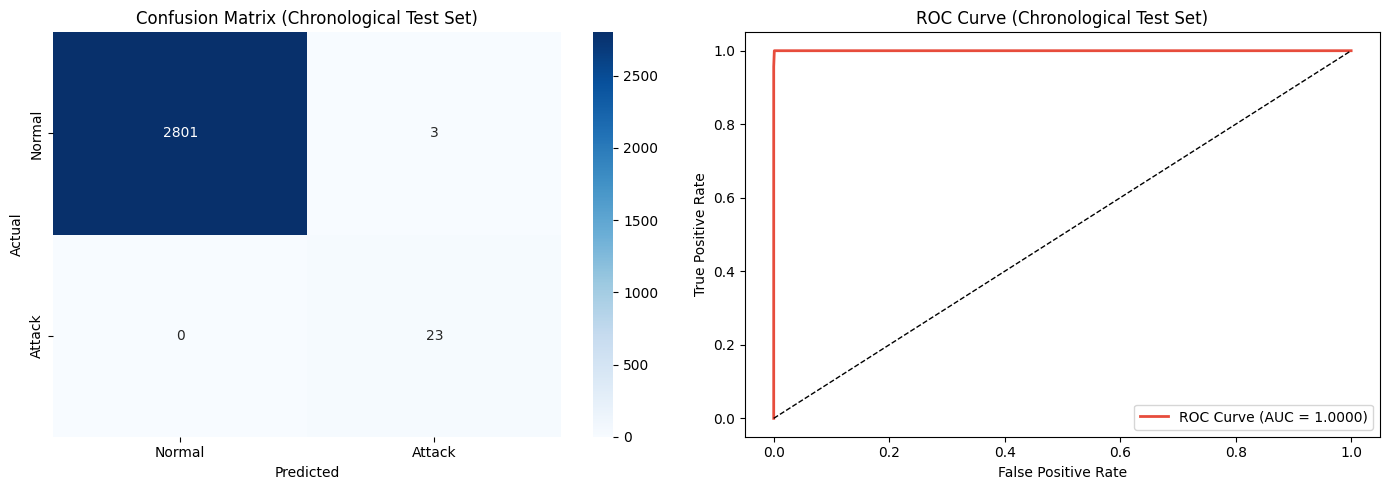


No major overfitting signal from F1 train-test gap.
Evaluation note: this setup is stricter than random splitting because adjacent packets remain in temporal order.


In [23]:
# Evaluate Decision Tree Model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

# Predictions
y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)
y_pred_proba_test = dt_model.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred_test)
overfit_gap = train_f1 - test_f1

# Baseline classifier for sanity check
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("=" * 70)
print("DECISION TREE - GENERALIZATION REPORT")
print("=" * 70)
print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | F1 Gap: {overfit_gap:.4f}")
print(f"Dummy Baseline Test Accuracy: {accuracy_score(y_test, dummy_pred):.4f}")
print(f"Dummy Baseline Test F1: {f1_score(y_test, dummy_pred, zero_division=0):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Attack']))

# Confusion Matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[0].set_title('Confusion Matrix (Chronological Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
auc_score = roc_auc_score(y_test, y_pred_proba_test)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve (Chronological Test Set)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

if overfit_gap > 0.10:
    print("\nOverfitting warning: Training F1 is notably higher than Test F1.")
else:
    print("\nNo major overfitting signal from F1 train-test gap.")

print("Evaluation note: this setup is stricter than random splitting because adjacent packets remain in temporal order.")

## Section 10: Visualize the Decision Tree

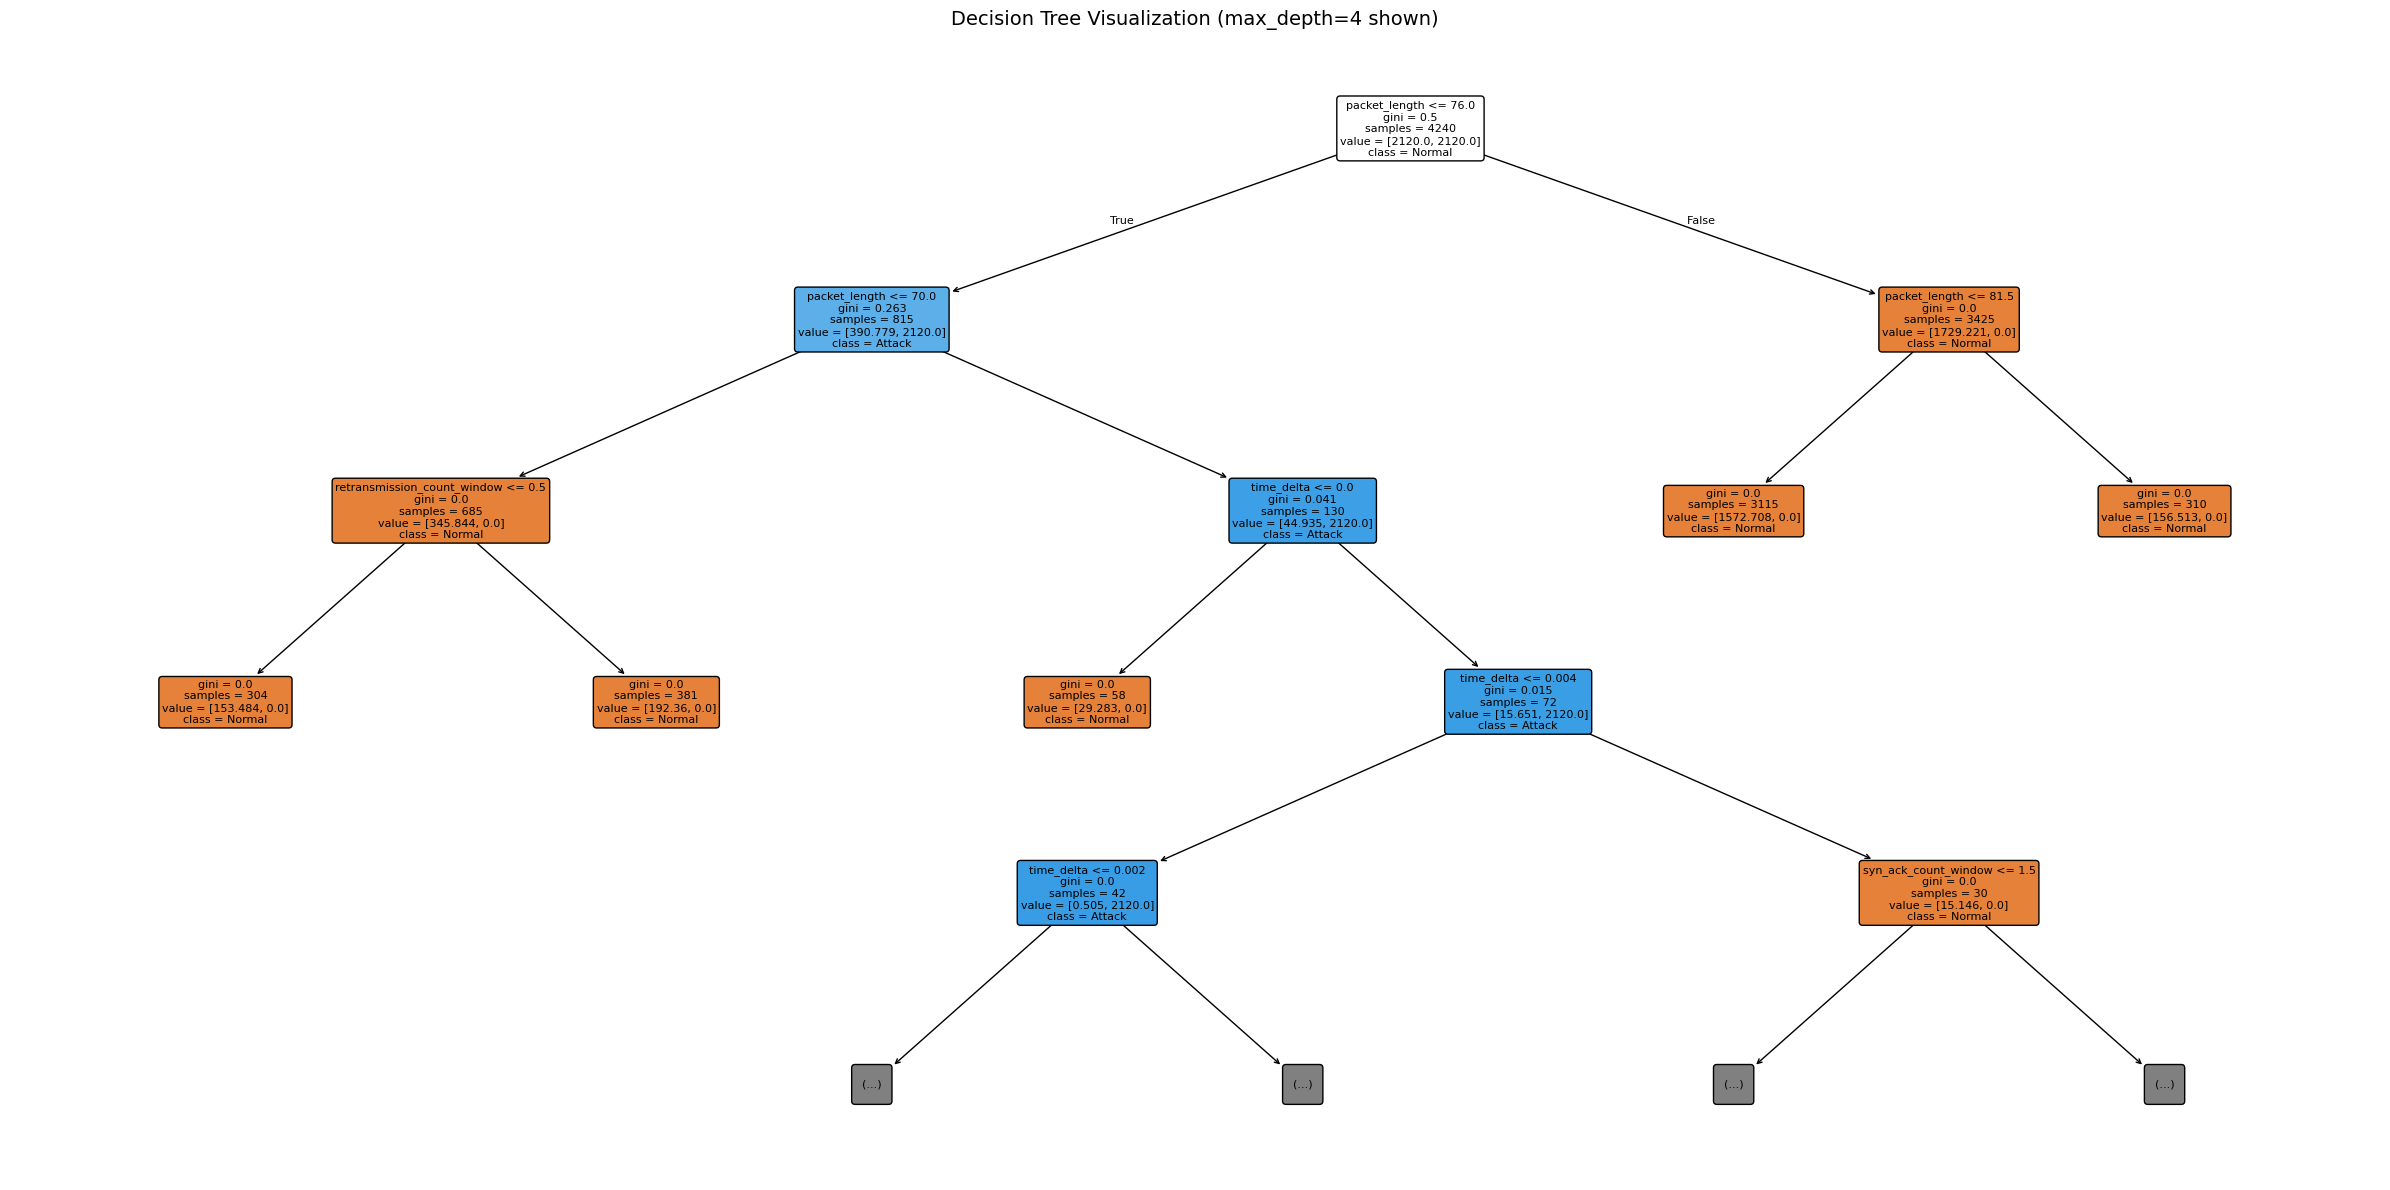


DECISION TREE RULES
|--- packet_length <= 76.00
|   |--- packet_length <= 70.00
|   |   |--- retransmission_count_window <= 0.50
|   |   |   |--- class: 0
|   |   |--- retransmission_count_window >  0.50
|   |   |   |--- class: 0
|   |--- packet_length >  70.00
|   |   |--- time_delta <= 0.00
|   |   |   |--- class: 0
|   |   |--- time_delta >  0.00
|   |   |   |--- time_delta <= 0.00
|   |   |   |   |--- time_delta <= 0.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- time_delta >  0.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- time_delta >  0.00
|   |   |   |   |--- syn_ack_count_window <= 1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- syn_ack_count_window >  1.50
|   |   |   |   |   |--- class: 0
|--- packet_length >  76.00
|   |--- packet_length <= 81.50
|   |   |--- class: 0
|   |--- packet_length >  81.50
|   |   |--- class: 0


--- Key Observations ---
The tree primarily splits on features related to:
  1. packet_length (importance: 0.9589)
  2. t

In [24]:
# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_model, feature_names=FEATURE_COLS, class_names=['Normal', 'Attack'],
          filled=True, rounded=True, ax=ax, fontsize=8, max_depth=4)
ax.set_title('Decision Tree Visualization (max_depth=4 shown)', fontsize=14)
plt.tight_layout()
plt.show()

# Export tree rules as text
print("\n" + "=" * 60)
print("DECISION TREE RULES")
print("=" * 60)
tree_rules = export_text(dt_model, feature_names=FEATURE_COLS, max_depth=5)
print(tree_rules)

print("\n--- Key Observations ---")
print("The tree primarily splits on features related to:")
top_features = importances.tail(5).index.tolist()[::-1]
for i, feat in enumerate(top_features, 1):
    print(f"  {i}. {feat} (importance: {dt_model.feature_importances_[FEATURE_COLS.index(feat)]:.4f})")